#### ASSIGNMENT-11

#### Tasks:

#### 1. Data Preparation:

Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv("C:/Users/jeevitha/Downloads/heart_disease(Description).csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           12 non-null     object
 1   Age in years  12 non-null     object
dtypes: object(2)
memory usage: 15.7+ KB


,age,Age in years
count,12,12
unique,12,12
top,Gender,"Gender ; Male - 1, Female -0"
freq,1,1


#### 2. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.

Check for missing values, outliers, and inconsistencies in the data.

Visualize the distribution of features, including histograms, box plots, and correlation matrices.

age             987
Age in years    987
dtype: int64


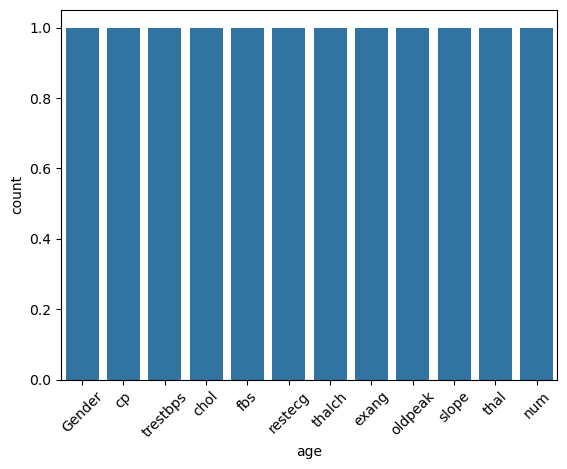

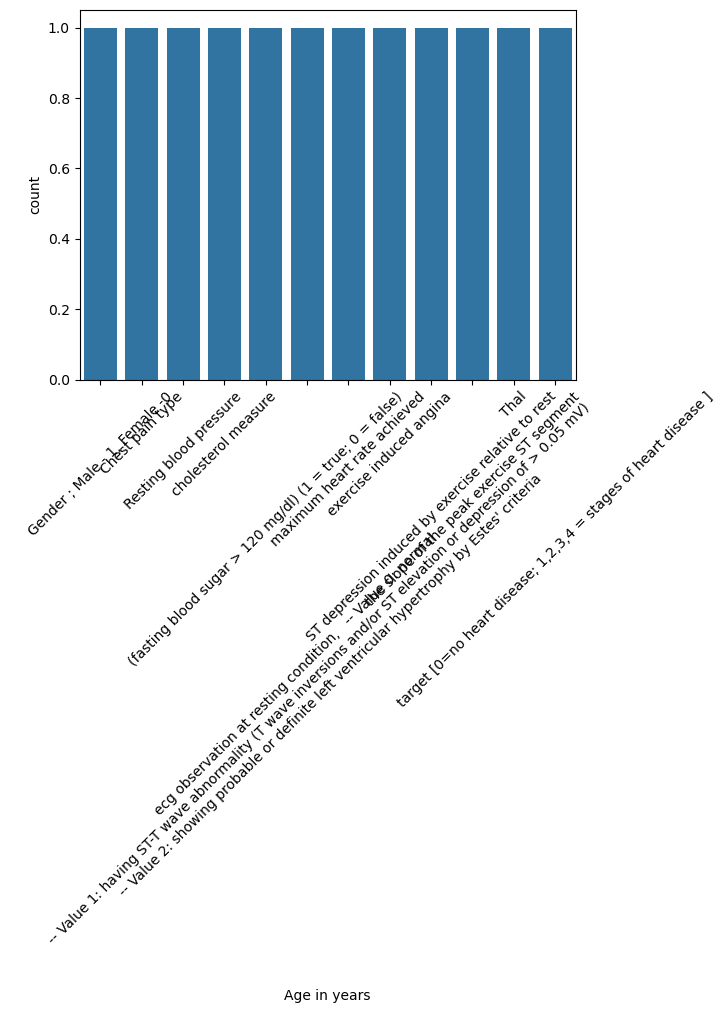

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check missing values
print(df.isnull().sum())

# Separate columns
num_cols = df.select_dtypes(include=['int64', 'float64'])
cat_cols = df.select_dtypes(include='object')

# Histograms (numerical)
if not num_cols.empty:
    num_cols.hist(figsize=(8,6))
    plt.show()

# Boxplot (outliers)
if not num_cols.empty:
    sns.boxplot(data=num_cols)
    plt.show()

# Correlation matrix
if not num_cols.empty:
    sns.heatmap(num_cols.corr(), annot=True)
    plt.show()

# Categorical plots
for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

#### 3. Feature Engineering:

If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

In [9]:
# Fill missing values

# Numeric → mean
df[num_cols.columns] = num_cols.fillna(num_cols.mean())

# Categorical → mode (FIXED version)
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Encode categorical data
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

#### 4. Decision Tree Classification:

Split the dataset into training and testing sets (e.g., using an 80-20 split).

Implement a Decision Tree Classification model using a library like scikit-learn.

Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Automatically select last column as target
target = df.columns[-1]

X = df.drop(target, axis=1)
y = df[target]

# Split data (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

#### 5. Hyperparameter Tuning:

Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

Accuracy: 0.995
Precision: 0.995
Recall: 0.995
F1 Score: 0.995


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


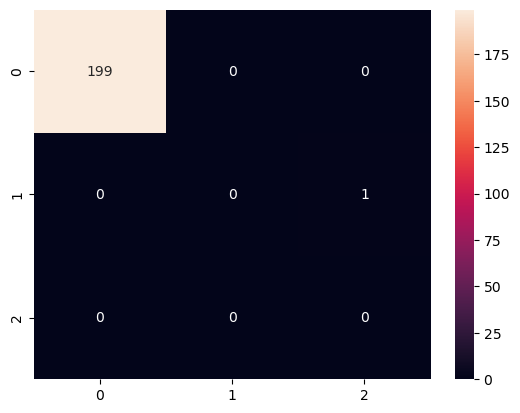

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

#### 6. Model Evaluation and Analysis:

Analyse the performance of the Decision Tree model using the evaluation metrics obtained.

Visualize the decision tree structure to understand the rules learned by the model and identify important features

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(), params, cv=3)
grid.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


#### Interview Questions:

#### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

#### Common Hyperparameters of Decision Tree

#### max_depth

Limits tree depth

Prevents overfitting

#### min_samples_split

Minimum samples required to split a node

#### criterion

Method to split data:

gini

entropy

#### Effect:

Large tree → overfitting

Small tree → underfitting

Proper tuning → better accuracy

#### 2.What is the difference between the Label encoding and One-hot encoding?

#### Label Encoding

Converts categories into numbers

Example: Red=0, Blue=1

Used for ordered data

#### One-Hot Encoding

Creates separate columns

Example:

Red → [1,0]

Blue → [0,1]

Used for unordered data